<a href="https://colab.research.google.com/github/IsaacFayle-Waters/AISO_True/blob/main/AISO_CW_Solving_TSP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Data Loading and Inspection / Environment Set-up


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import numpy as np
import pandas as pd
import random

import matplotlib.pyplot as plt
import networkx as nx
import timeit

from collections import deque, defaultdict

path = '/content/drive/MyDrive/Uni-Masters/AIOptSearch/asessment/cities.csv'
df = pd.read_csv(path)

In [ ]:
SEED = 27
np.random.seed(SEED)  #legacy numpy
rng = np.random.default_rng(seed=SEED)
#random.seed(SEED)  # Python's built-in random

In [ ]:
print('Problem Size (number of cities) : ', len(df))
print(df.head(2))

Problem Size (number of cities) :  50
     City          X          Y
0  City_1  37.454012  95.071431
1  City_2  73.199394  59.865848


# Travelling Salesman Problem (TSP)

A salesman must visit a series of cities exactly once, and return home.

There is an exponential increase in complexity for each additional city in a TSP problem O(n!) (Entesar Alanzi and El, 2025); as such, there may not be a single optimal solution.

### Shared Variation Operators
For Simulated Annealing, 2-opt was implemented, as was ‘inversion’ for the Genetic Algorithm -  these are functionally analogous. Both swap two cities, and invert the sub-tour between them. The advantage is that this operator will always untangle TSP problems, eventually ensuring that no edges cross (Baeck, Fogel and Michalewicz, 2018, pp.19, 186).


### Objective Function
Minimizing the distance of each tour, in this case calculated using Euclidean Distance.


In [ ]:
#Problem Definition Class
class TSP:
  def __init__(self, node_df: pd.DataFrame) -> None:
      self.city_nodes = node_df
      self.problem_size = len(self.city_nodes)
      self.cities = []
      self.coords = []
      self.distance_matrix = np.zeros((self.problem_size, self.problem_size))

      #For visualisation and measurement
      self.optim_name = str()
      self.error = []
      self.evaluation_count = 0 #Keeping track of convergence

  def get_node_parameters(self):
      '''
      Description: Extracts cities and their coordinates from `self.city_nodes`
      DataFrame.
      '''
      self.cities = [city for city in self.city_nodes['City']]
      self.coords = list(zip(self.city_nodes.X, self.city_nodes.Y)) # Claud.ai helped with zipping logic

  def calc_euclidean(self,
                     first_city_xy1: list[float],
                     second_city_xy2: list[float]) -> np.float64:
      '''
      Parameters: list[[x],[y]], list[[x],[y]]
      Returns: numpy.float64

      Description: calculates euclidian distance between two sets of co-ordinates.
      '''
      #np.sqrt((x2-x1)^2 + (y2-y1)^2))
      return np.sqrt((second_city_xy2[0] - first_city_xy1[0])**2 + (second_city_xy2[1] - first_city_xy1[1])**2)

  def calc_distance_matrix(self):#Basic functionality from claude.ai
      '''
      Description: Calculates the distances between all cities from their coordinates.
      '''
      for i in range(self.problem_size):
          for j in range(self.problem_size):
              if i != j:
                  self.distance_matrix[i][j] = self.calc_euclidean(self.coords[i], self.coords[j])

  def objective_function(self, tour: list[int]) -> np.float64:#Basic Functionality from claude.ai
      '''
      Parameters: list
      returns: np.float64

      Description: Return the total distance for a tour. The objective function for TSP.
      Returns from last city visited to first city.
      '''
      self.evaluation_count += 1
      total_distance = 0
      for i in range(len(tour) - 1):
        total_distance+= self.distance_matrix[tour[i], tour[i + 1]]

      total_distance += self.distance_matrix[tour[-1], tour[0]]
      #print(tour[-1], tour[0])
      return total_distance

  def sanity(self):
      '''
      Description: Sanity check that evaluates wether objective function calculates
      as expected.
      '''
      #Proof
      tour = [0,1,2]
      tour_score = self.objective_function(tour)
      print(tour_score)
      print(self.distance_matrix[0][1]
            + self.distance_matrix[1][2]
            + self.distance_matrix[2][0])

  '''
  LOCAL SEARCH METHODS:
  Some functions can be shared between tabu, sa, and hillclimbing. i.e.
  generating initial solutions, and city swapping / neighbor generation .
  '''

  def generate_initial_point(self) -> list[int]:
      '''
      Returns: list[int]

      Description: Generates list of integers as long as the problem size (number of cities),
      then shuffles the list to return a random initial point
      '''
      tour = [i for i in range(0, self.problem_size)]
      rng.shuffle(tour)

      return tour

  def swap_cities_get_neighbour(self,
                                tour: list[int], i=None, j=None) -> list[int]: # Some help from claude.ai with basic functionality of swap behaviour
      '''
      Description: Main city swapping function. Adapted for various algorithms:
      The extra i = None nonsence is for tabu search.
      For GA and SA, only the operators themselves mean anything
      '''
      new_tour = tour.copy()

      if i is None or j is None:
        i,j = rng.choice(range(len(tour)), size = 2, replace=False)

      if self.step_size == 'simp_swap':
        new_tour[i], new_tour[j] = new_tour[j], new_tour[i]

      elif self.step_size == '2opt':
        if i > j:
          i,j = j,i
        new_tour[i:j+1] = list(reversed( new_tour[i:j+1]))

      else:
        print('Incorrect step_size recieved!')

      return new_tour, (tour[i],tour[j])

  def get_all_neighbours_swaps(self, tour):
    '''
    FOR TABU - PLEASE IGNORE!

    '''
      #https://www.geeksforgeeks.org/dsa/what-is-tabu-search/
      #Also suggestions from Claude.ai (some helpful some not)
      neighbours = []
      for i in range(len(tour)):
        for j in range(i + 1, len(tour)):
          #new_tour = tour.copy() #Handled elsewhere
          neighbour, swap = self.swap_cities_get_neighbour(tour, i, j)
          neighbours.append((neighbour, (swap)))

      return neighbours


  '''
  VISUALISATION AND MEASUREMENT METHODS
  '''

  def convergence_graphing(self):#Basic logic claude, my own tweaks for class stuff and naming
      '''Plots the reduction in error over the run of an algorithm'''
      #Create canvas and plot convergence
      plt.figure(figsize=(12, 6))
      plt.plot(self.error, alpha=0.9, label='Current solution')

      plt.xlabel('Iteration')
      plt.ylabel('Error')
      plt.title('Convergence -> ' + self.optim_name)#Get optimisor name from individual algorithms

      plt.legend()
      plt.grid(True)
      #plt.savefig(f'Convergence:{self.optim_name}.png')
      plt.show()

  def vis_problem_space(self, tour: list[int] = None ):
    '''
    Description: Creates node graphs using networkx
    '''
    #networkx code from chatGPT
    G = nx.Graph()
    for i, (x,y) in enumerate(self.coords):
      G.add_node(i,pos=(x,y))
    #Unexplored Graph
    if tour is None:
      pos = nx.get_node_attributes(G, 'pos')
      nx.draw(G, pos, with_labels=True, node_size=400)
      plt.show()
    #Graph with tour
    else:
      edges = [(tour[i], tour[(i + 1) % len(tour)]) for i in range(len(tour))]
      G.add_edges_from(edges)
      pos = nx.get_node_attributes(G, 'pos')
      nx.draw(G, pos, with_labels=True, node_size=300, font_size=8)
      nx.draw_networkx_edges(G, pos, edgelist=edges, width=2)
      #plt.savefig(f'Node Graph: {self.optim_name}.png')
      plt.show()

  def average_edge_length(self,tour):
    '''Provides a measurement of average edge length fromm node to node'''
    n = len(tour)
    edges = [self.distance_matrix[tour[i]][tour[(i + 1) % n]] for i in range(n)]
    return np.mean(edges)

  def to_external_file(self, best_tour: list[int] = None) -> None:
    '''
    Description: Creates a .csv that needs to be included in the the final coursework.
    Also converts tour back into 'city_n' form, adjusting for index 1-50.
    '''
    path = f"Optimal_Path_from_{self.optim_name}.csv"
    #Path and get length
    to_file_tour = best_tour.copy()
    n = len(to_file_tour)

    #Most of this file treats 'city_1' as '0', so this needs to be adjusted for the final file.
    #Also, The final edge is always assumed and accounted for implicitly,
    #so here it is added back in manually.
    cities_adjusted = [f'city_{to_file_tour[i] + 1}' for i in range(n)] + [f'city_{to_file_tour[0] + 1}']
    #print(cities_adjusted)
    pd.DataFrame(cities_adjusted, columns=['Tour Order']).to_csv(path, index=False)





Initial Unexplored Problem Space


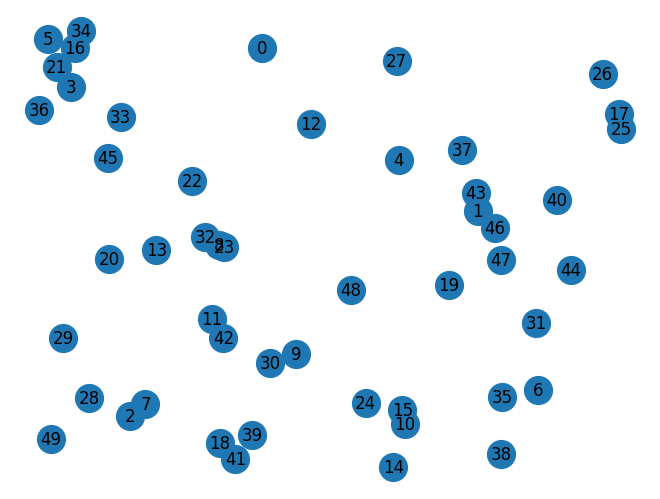

In [ ]:
# @title
tsp = TSP(df)
tsp.get_node_parameters()
tsp.calc_distance_matrix()

print('Initial Unexplored Problem Space')
tsp.vis_problem_space()

Solution Generated at Random. This tour has a distance of 2707.081356454984


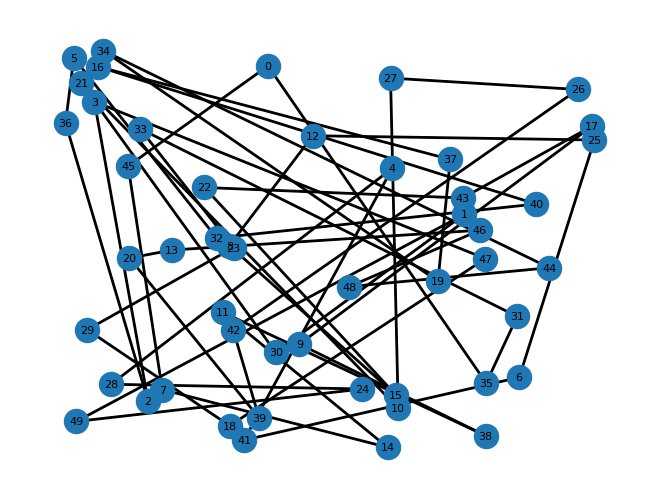

In [ ]:
# @title
random_solution = tsp.generate_initial_point()
print(f'Solution Generated at Random. This tour has a distance of {tsp.objective_function(random_solution)}')
tsp.vis_problem_space(random_solution)

In [ ]:
# @title
random_tour_edge_avg = []
for i in range(10):
  random_solution = tsp.generate_initial_point()
  random_tour_edge_avg.append(tsp.average_edge_length(random_solution))

print(f'Aveage city to city/node to node distance for randomly generated tours: {np.mean(random_tour_edge_avg):.2f}')

Aveage city to city/node to node distance for randomly generated tours: 54.73


### Single-Solution vs Population-driven
Single-solution-driven search algorithms use a single initial solution to derive additional solutions. Population-driven algorithms use an initial population of solutions.


### Pre-Comparison Single-Solution Experiments
To gain a better understanding of Single-Solution algorithms and to refresh Python understanding, a small range of algorithms were implemented, with a view to selecting the best performing for the final Main Comparison.  

### Hill Climbing (Steepest Ascent)

In [ ]:
class HillClimbingTSP(TSP):#Steepest ascent
  def __init__(self, node_df: pd.DataFrame, n_iterations: int = 100) -> None:
     super().__init__(node_df)

     self.ittr = n_iterations

  def hill_climbing(self):
    #Generate intial solution and evaluate
    current_tour_hc = self.generate_initial_point()
    current_eval_hc = self.objective_function(current_tour_hc)
    #Run Algorithm
    for i in range(self.ittr):
      neighbours = self.get_all_neighbours_swaps(current_tour_hc)
      #Evaluate all neighbours of current solution and compare with current solution
      for neighbour, _ in neighbours:
        neighbour_eval = self.objective_function(neighbour)
        if neighbour_eval < current_eval_hc:
          current_tour_hc = neighbour
          current_eval_hc = neighbour_eval

      self.error.append(current_eval_hc)
    self.optim_name = f"Hill Climbing (stp asc) : step = {self.step_size}, ittr = {self.ittr}"
    return[current_tour_hc, current_eval_hc]


Shortest route found by Hillclimbing : 559.8646560201398


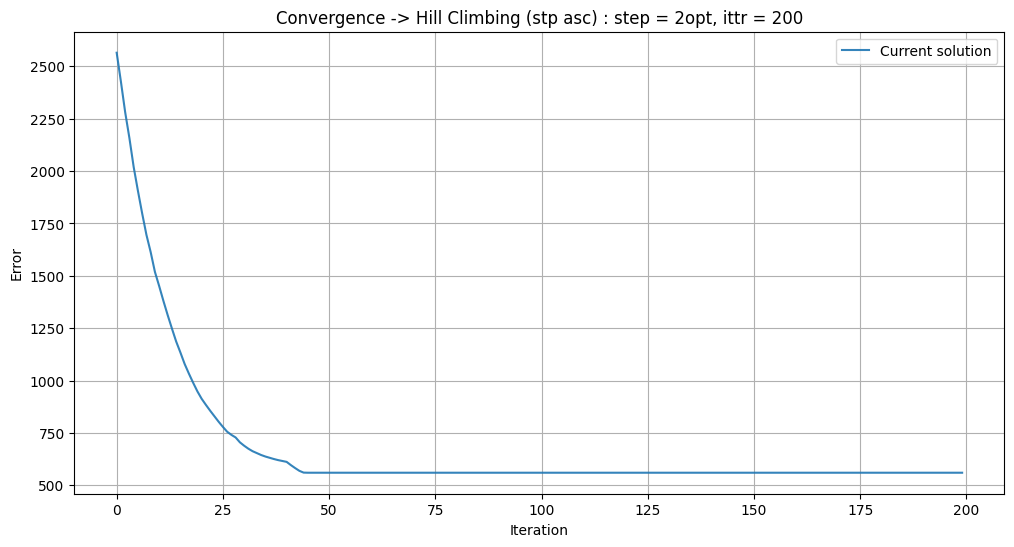

In [ ]:
rng = np.random.default_rng(seed=27)
hc = HillClimbingTSP(df,n_iterations=200)
hc.get_node_parameters()
hc.calc_distance_matrix()
hc.step_size = '2opt'

best_tour_hc, shortest_distance_hc = hc.hill_climbing()
print(f'Shortest route found by Hillclimbing : {shortest_distance_hc}')
hc.convergence_graphing()

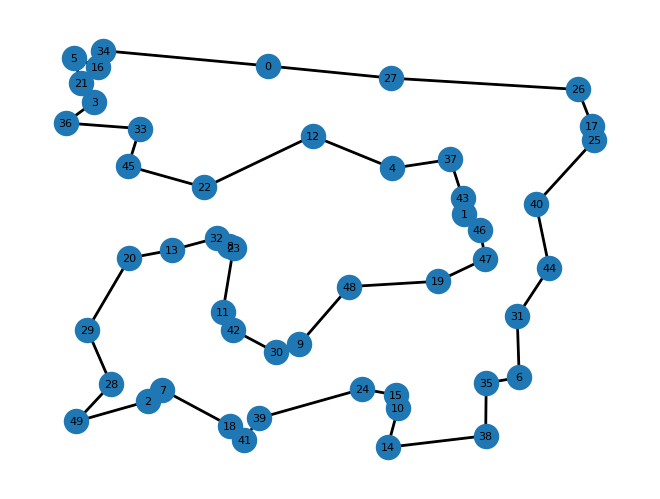

In [ ]:
hc.vis_problem_space(best_tour_hc)

## 1. Simulated Annealing

In [ ]:
class SimulatedAnnealingTSP(TSP):
  def __init__(self,
               node_df: pd.DataFrame,
               temperature: float = 10,
               alpha: float = 0.995,
               step_size: str = 'simp_swap',
               n_iterations: int = 100) -> None:
     #Inherit methods and parameters from TSP
     super().__init__(node_df)

     self.temp = temperature
     self.step_size = step_size
     self.itter = n_iterations
     self.alpha = alpha

  def simulated_annealing(
      self,
      show: bool = False
      ) -> tuple[list[int], np.float64, list[float], list[float]]:
    # Based on simulated annealing from workbook 'Simulated_Annealing_Tutorial.ipynb'
    '''
    Parameters: bool
    Returns: list, float64, list, list

    Description: Simulated Annealing algorithm, capable of simple swapping or 2opt.

    '''
    self.evaluation_count = 0
    #lists to collect solutions for graphing
    best_scores = list()
    current_scores = list()

    #Generate an initial point
    best_tour = self.generate_initial_point()

    #Evaluate initial point
    best_tour_eval = self.objective_function(best_tour)

    #Make best current
    curr_tour, curr_tour_eval = best_tour, best_tour_eval

    #Run algorithm
    for ittr in range(self.itter):
      #take a step / swap
      candidate_tour, _ = self.swap_cities_get_neighbour(curr_tour)
      #Evaluate candidate tour
      candidate_tour_eval = self.objective_function(candidate_tour)

      #Check for new best tour
      if candidate_tour_eval < best_tour_eval:
        best_tour, best_tour_eval = candidate_tour.copy(), candidate_tour_eval
        best_scores.append(best_tour_eval)
        if show == True:
          #report Change
          #print(f"Lowest Distance Found : {best_tour_eval} @ ittr {ittr}")
          self.vis_problem_space(best_tour)

      #Calculate difference
      diff = candidate_tour_eval - curr_tour_eval

      #Calculate temp for current epoch
      #t = self.temp / float(ittr + 1)
      #Geometric cooling (more gradual according to claude)
      alpha = self.alpha
      t = self.temp * (alpha ** ittr)

      #calculate metropolis acceptance criterion
      metropolis = np.exp(-diff / t)

      if diff < 0 or rng.random() < metropolis:
        curr_tour, curr_tour_eval = candidate_tour.copy(), candidate_tour_eval

      #For Graphing error over time
      self.error.append(curr_tour_eval)

    self.optim_name = f"Simulated Annealing: Temp = {self.temp}, Step = {self.step_size}, n_ittr = {self.itter}"

    return [best_tour, best_tour_eval, best_scores]

In [ ]:
rng = np.random.default_rng(seed=34)
#'Perfect' run
sa = SimulatedAnnealingTSP(df,
                            temperature=16,
                            step_size='2opt',
                            alpha = 0.999,
                            n_iterations=5500)
#Construct problem space
sa.get_node_parameters()
sa.calc_distance_matrix()

#Run SA algorithm
best_tour_sa, shortest_distance_sa, best_scores = sa.simulated_annealing()

print(f"Best tour length : {shortest_distance_sa}")
print('Best Tour :\n', best_tour_sa)

Best tour length : 559.8646560201398
Best Tour :
 [19, 47, 46, 1, 43, 37, 4, 12, 22, 45, 33, 36, 3, 21, 5, 16, 34, 0, 27, 26, 17, 25, 40, 44, 31, 6, 35, 38, 14, 10, 15, 24, 39, 41, 18, 7, 2, 49, 28, 29, 20, 13, 32, 8, 23, 11, 42, 30, 9, 48]


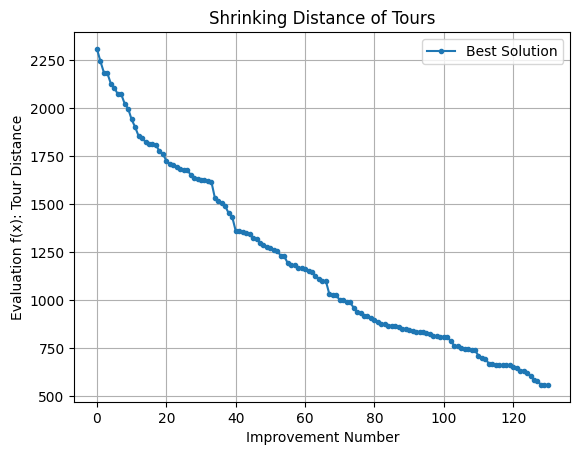

In [ ]:
# line plot of best scores
plt.plot(best_scores, '.-', label = 'Best Solution')
plt.xlabel('Improvement Number')
plt.ylabel('Evaluation f(x): Tour Distance')
plt.title('Shrinking Distance of Tours')
plt.legend()
plt.grid(True)
plt.show()

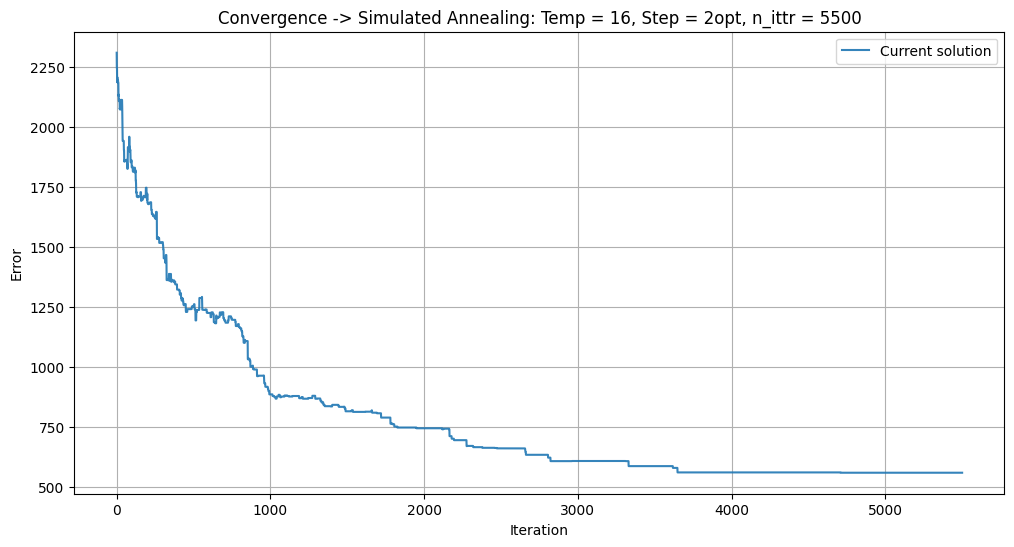

In [ ]:
sa.convergence_graphing()

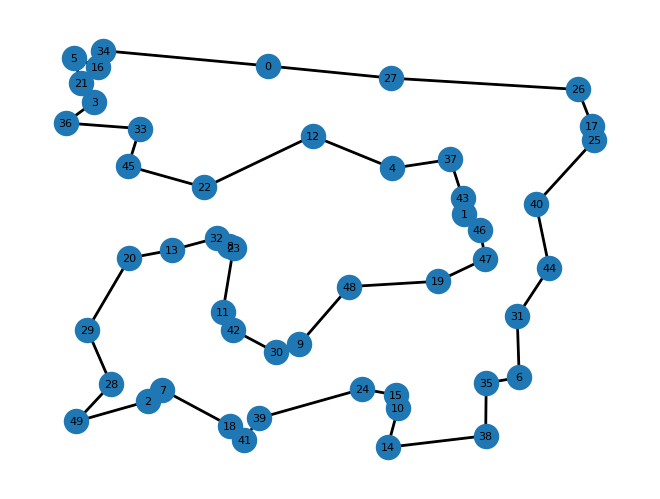

In [ ]:
sa.vis_problem_space(best_tour_sa)

In [ ]:
avg_perfect_sa = sa.average_edge_length(best_tour_sa)
print('Aveage city to city/node to node distance', avg_perfect_sa)

Aveage city to city/node to node distance 11.197293120402799


##Tabu Search


In [ ]:
# @title
class TabuSearch(TSP):
  def __init__(self,
               node_df: pd.DataFrame,
               tabu_tenure: int = 3,
               n_iterations: int = 10,
               lt_performance_weight: float = 0.001) -> None:
    super().__init__(node_df)

    self.tabu_tenure = tabu_tenure
    self.ittr = n_iterations

    '''
    My explanaition to myself.
    Short term memory tabu list: Deque acts like a drainpipe of length 'tenure'.
    If A,B,C,D are tennis balls, put into the drainpipe right to left, and the
    pipe has a tenure/capacity of 3 balls, the pipe would hold [B,C,D] at the
    end of the activity. And you would be happy.

    '''
    self.st_memory = deque(maxlen=tabu_tenure)
    #long term memory TBC
    self.lt_performance_weight = lt_performance_weight
    self.lt_memory = defaultdict(int)#advised by chatGPT

  def tabu_search(self, show: bool = False) -> tuple[list[int], np.float64]:
    # sort of following https://www.geeksforgeeks.org/dsa/what-is-tabu-search/ and claude.ai
    # with reference to worksheet
    '''
    Parameters: bool
    Returns: list[int], float
    Description:

    long-term memory inspired by the following:
    - https://github.com/taylankabbani/Metaheuristic-Algorithms-for-SMTWTP/blob/master/TS_longMemmory.py
    - claude.ai
    - chatGPT

    '''
    #Initialize current/best
    current_tour_tb = best_tour_tb = self.generate_initial_point()
    current_eval_tb = best_eval_tb = self.objective_function(best_tour_tb)

    for i in range(self.ittr):
      best_neighbour = None
      best_neighbour_eval = np.inf
      best_swap = None

      #get neighbours of best tour
      neighbors_and_swaps = self.get_all_neighbours_swaps(current_tour_tb)

      #Evaluate neighbours if not taboo
      for neighbour, swap in neighbors_and_swaps:
        #self.lt_memory[swap] = 0
        if (swap not in self.st_memory) or (self.objective_function(neighbour)#aspiration: Commenting it out showed no impact so might be wrong?
                                          < best_eval_tb) :
          #Claude.ai spotted a bug in my implementation, and suggested comparing with adjusted and base evals: TODO: investigate claim
          base_eval = self.objective_function(neighbour)
          #Calculating a frequency penalty for long term memory.
          #It's possible that the problem size is too small for either ltm or aspiration to make much of a difference.
          freq_pen = self.lt_memory[swap] * self.lt_performance_weight
          adjusted_eval = self.objective_function(neighbour) + freq_pen
          if adjusted_eval < best_neighbour_eval:
            best_neighbour = neighbour
            best_neighbour_eval = base_eval
            best_swap = swap

      if best_swap == None:
        #All Neighbours are taboo. End search.
        break

      current_tour_tb = best_neighbour

      self.st_memory.append(best_swap)
      self.lt_memory[best_swap] += 1

      if best_neighbour_eval < best_eval_tb:
        best_tour_tb = best_neighbour
        best_eval_tb = best_neighbour_eval
        if show == True:
          self.vis_problem_space(best_neighbour)
          #print(f"Shortest Distance : {best_eval_tb} found @ ittr {i}")

      self.error.append(best_eval_tb)

    self.optim_name = f"Tabu Search : Tenure = {self.tabu_tenure}, step_size = {self.step_size}, ittr = {self.ittr}"
    return [best_tour_tb, best_eval_tb]


In [ ]:
rng = np.random.default_rng(seed=27)
tenure = 10
tbs = TabuSearch(df,
                 tabu_tenure=tenure,
                 n_iterations=150,
                 lt_performance_weight=1)
tbs.get_node_parameters()
tbs.step_size = '2opt'
tbs.calc_distance_matrix()

best_tour_tb, shortest_distance_tabu = tbs.tabu_search(show=False)

print(f'''Shortest tour using short-term memory only, with a tenure of {tenure}:
{best_tour_tb}
With a distance of {shortest_distance_tabu}''')

Shortest tour using short-term memory only, with a tenure of 10:
[32, 8, 23, 11, 42, 30, 9, 48, 19, 47, 46, 1, 43, 37, 4, 12, 22, 45, 33, 36, 3, 21, 5, 16, 34, 0, 27, 26, 17, 25, 40, 44, 31, 6, 35, 38, 14, 10, 15, 24, 39, 41, 18, 7, 2, 49, 28, 29, 20, 13]
With a distance of 559.8646560201398


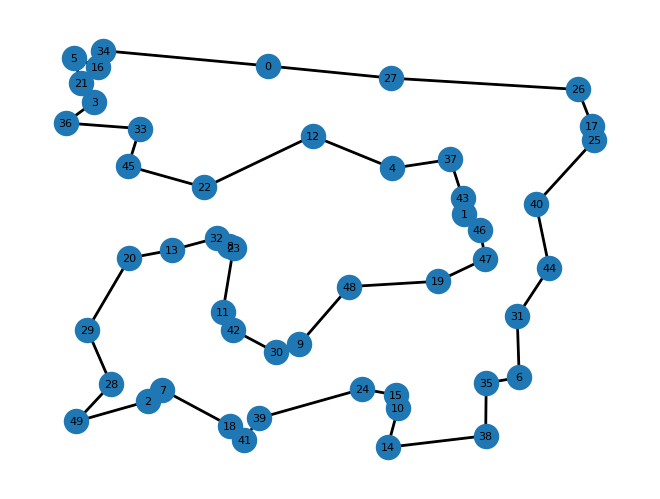

In [ ]:
tbs.vis_problem_space(best_tour_tb)

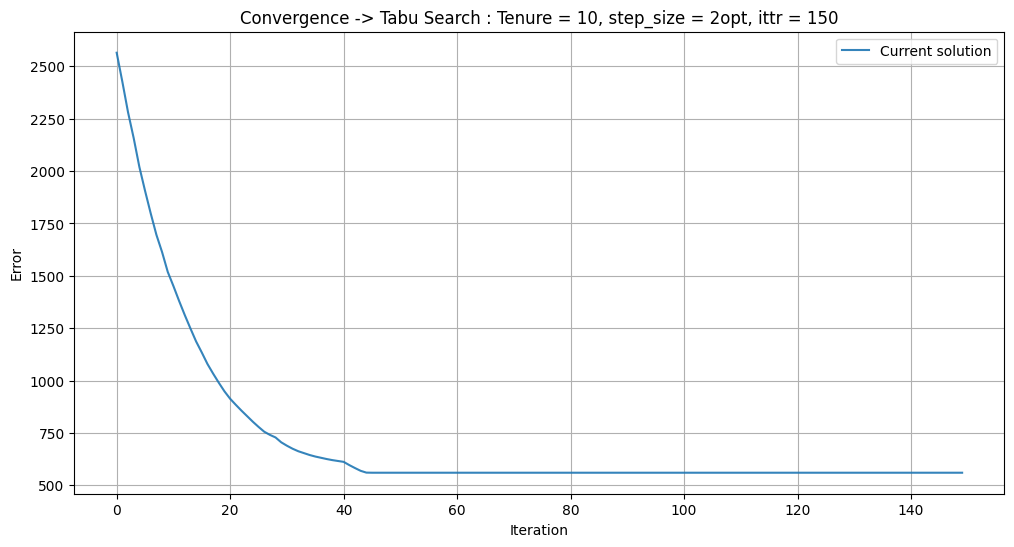

In [ ]:
tbs.convergence_graphing()

## 2. Genetic Algorithm

In [ ]:
class GeneticAlgorithm(TSP):
  def __init__(self, node_df: pd.DataFrame,
               population_size: int = 50,
               generations: int = 100,
               mutation_rate: float = 0.02,
               crossover_rate: float = 0.8 ,
               tornement_size: int = 3,
               operator: str = 'simp_swap') -> None:
     super().__init__(node_df)
     #GA specific parameters
     self.population_size = population_size
     self.generations = generations
     self.mutation_rate = mutation_rate
     self.crossover_rate = crossover_rate
     self.tornement_size = tornement_size
     self.operator = operator

  def generate_popualtion(self):
    return [self.generate_initial_point() for i in range(self.population_size)]

  def create_child(self, chromosome_one, chromosome_two):#Claude.ai helpded with helper
    'Helper function to create a single child using order crossover.'
    size = len(chromosome_one)

    #Select random segment from chromosome_one
    start, end = sorted(rng.choice(range(size), size=2, replace=False))

    #Copy segment
    child = [None] * size
    child[start:end+1] = chromosome_one[start:end+1]

    #Fill remaining positions using chromosome_two
    chromosome_two_mask = [gene for gene in chromosome_two if gene not in child]#PREVENTS GENE DUPLICATION
    index = 0
    for i in range(size):
        if child[i] is None:
            child[i] = chromosome_two_mask[index]
            index += 1

    return child

  def order_crossover(self, chromosome_one, chromosome_two):
    '''
    Description: Takes two parent chromosomes, and has a probability of crossing
    them using the helper function `create_child`, by copying and then merging
    segments from one parent into the other.

    '''
    if rng.random() < self.crossover_rate:#chance of not crossing
          #If crossing get children
          child_one = self.create_child(chromosome_one, chromosome_two)
          child_two = self.create_child(chromosome_two, chromosome_one)
    else:#PArents returned
        child_one = chromosome_one.copy()
        child_two = chromosome_two.copy()

    return child_one, child_two

  def mutation(self, chromosome):
    '''
    Description: Mutation Operator.
    Actually just uses other operators to mutate genes, except theres a
    probability it won't make the swap, and returns the original.
    '''
    if rng.random() < self.mutation_rate:
      if self.operator == 'simp_swap':

        self.step_size = self.operator
        mutated_chromosome,_ = self.swap_cities_get_neighbour(chromosome)

        return mutated_chromosome

      elif self.operator == 'inversion':#Same as 2opt, really
        mutated_chromosome = chromosome.copy()
        start, end = sorted(rng.choice(range(len(mutated_chromosome)), size=2, replace=False))
        mutated_chromosome[start:end+1] = list(reversed(mutated_chromosome[start:end+1]))
        return mutated_chromosome

      elif self.operator == 'memetic':#Inversion is same, not memetic?

        self.step_size = '2opt'#Actually inversion
        mutated_chromosome,_ = self.swap_cities_get_neighbour(chromosome)
        return mutated_chromosome

      else:
        print('Invalid Operator Selection!')
        return None
    return chromosome

  def tornement_selection(
      self,
      population: list[int] = None,
      scores: list[np.float64] = None):
    k = self.tornement_size
    challenger = rng.integers(0, self.population_size)#Pick a candiate at random to act as a highest
    for i in rng.integers(0, self.population_size, k - 1 ):#k = number of candidates in tornement
      if scores[i] < scores[challenger]:#if score of candidate better than (intitialy random) selction, change selection to new candidate
        challenger = i
    return population[challenger]


  def genetic_algorithm(self,elite=False):
    '''
    Main GA function. The actual algorithm
    '''
    self.evaluation_count = 0
    population = self.generate_popualtion()

    # Track the best solution and fitness
    best_solution = population[0]
    best_fitness = self.objective_function(best_solution)
    #print(best_fitness)
    #print(best_solution)
    for generation in range(self.generations):
      scores = [self.objective_function(i) for i in population]

      for i in range(self.population_size - 1):
        if scores[i] < best_fitness:
          best_fitness = scores[i]
          best_solution = population[i]

          #print(f'''
          #Score = {scores[i]} @ Generation {generation}
          #for solution{best_solution}''')

      #selection
      selected = [self.tornement_selection(population, scores) for _ in range(self.population_size)]

      children = list()
      for i in range(0, self.population_size, 2):
        parent_1, parent_2 = selected[i], selected[i + 1]

        #crossover
        for child in self.order_crossover(parent_1, parent_2):
          mutated_child = self.mutation(child)
          #save for next gen
          children.append(mutated_child)

      population = children
      if elite == True:
        population[0] = best_solution

      self.error.append(best_fitness)

    self.optim_name = f'''Genetic Alg: operator: {self.operator} pop_size: {self.population_size} generations: {self.generations}
    mutation_rate: {self.mutation_rate} torn_size ={self.tornement_size} cross_rate: {self.crossover_rate}'''
    return best_solution, best_fitness




Shortest tour ga : 559.8646560201398 seed @ 7


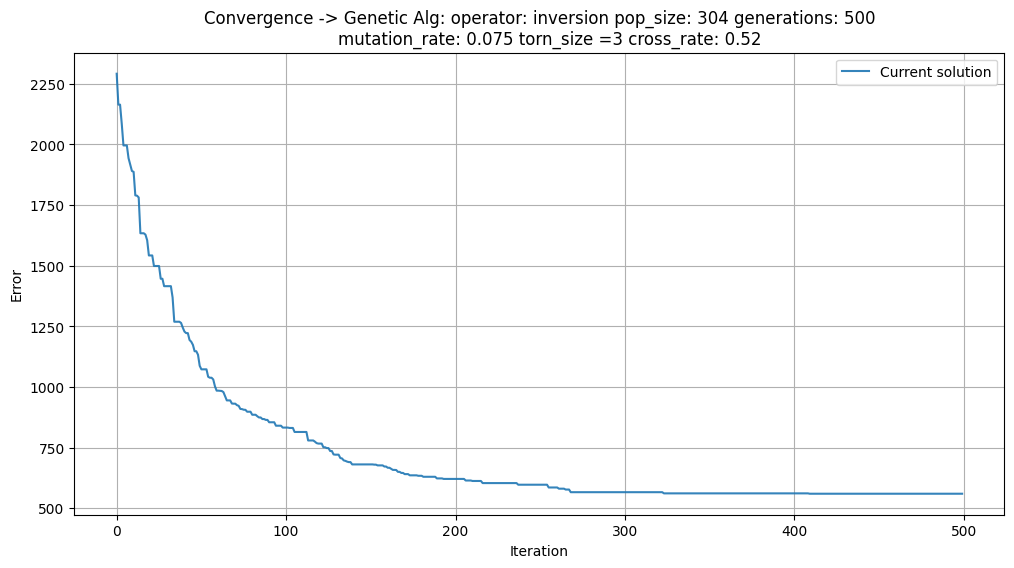

In [ ]:
rng = np.random.default_rng(seed=7)
ga_solved = GeneticAlgorithm(df,
                        population_size=304,#Mean: 587.400102107916 std: 9.784733558545613 @ tourne_size 286)
                        generations=500, #500
                        mutation_rate=  0.075, #0.085, #0.085
                        crossover_rate= 0.52, #0.99
                        tornement_size=3, #3 or 7 (3 lower std, 7 better mean. Mean only slightly better)
                        operator='inversion') #inversion
ga_solved.get_node_parameters()
ga_solved.calc_distance_matrix()
best_tour_ga_solved, shortest_distance_ga_solved = ga_solved.genetic_algorithm()
print(f'Shortest tour ga : {shortest_distance_ga_solved} seed @ {7}')
ga_solved.convergence_graphing()

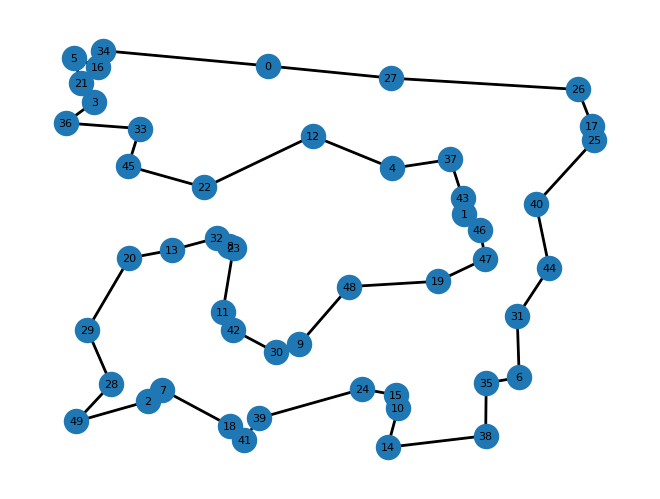

In [ ]:
ga_solved.vis_problem_space(best_tour_ga_solved)

In [ ]:
ga_perfect_avg = ga_solved.average_edge_length(best_tour_ga_solved)

print('Aveage city to city/node to node distance', ga_perfect_avg)

Aveage city to city/node to node distance 11.197293120402797


In [ ]:
ga_solved.to_external_file(best_tour_ga_solved)

## Comparisons: Simple Swapping

The operation whereby two cities exchange places during the search for a solution can be completed in the most basic terms by swapping one city in a tour with another. However, better results can be observed in Table 1, by using '2-opt' swaps, whereby the route (order of cities visited) betwen the two cities being swapped are reversed.

The results in Table 1 suggest that swapping operator type may be more important than the algorithm used in this instance of TSP.


|  | GA (inversion/2opt) | GA (Simple Swap) | SA (2-opt) | SA (Simple Swap) |
| ----- | :---: | :---: | :---: | :---: |
| Avg Convergence | **586.645** | 744.983 | 627.638 | 917.589 |
| Convergence Variation (std) | **9.446** | 49.836 | 15.187 | 55.105 |
| Avg Edge Length | **11.733** | 14.900 | 12.553 | 18.352 |

 Table 1: Operator Differences over 50 cities \- 2-opt completely outperforms simple swapping

### Simp Swap Algorithms

Shortest route found by Hillclimbing : 828.1646523152251


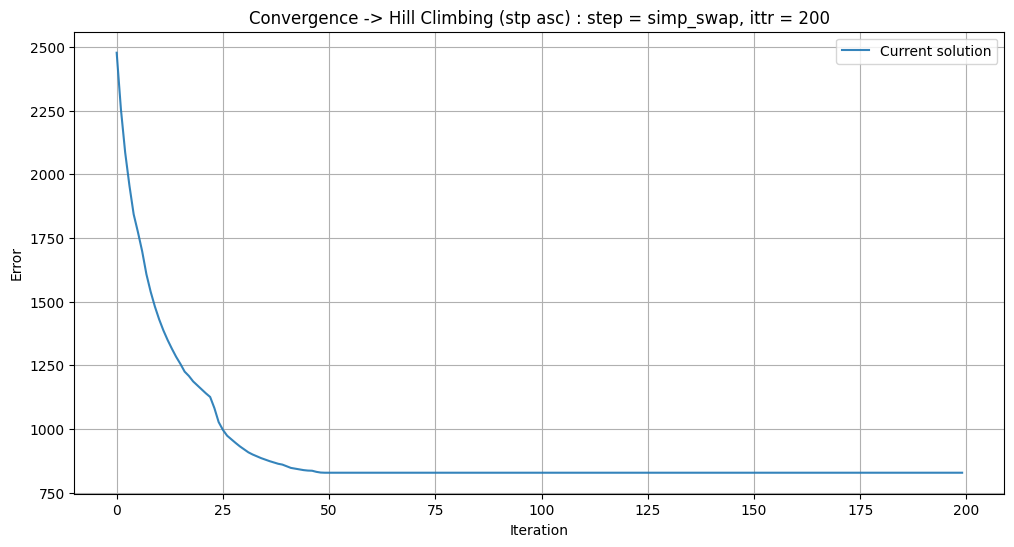

In [ ]:
#Hill climb
rng = np.random.default_rng(seed=27)
hc_simp = HillClimbingTSP(df,n_iterations=200)
hc_simp.get_node_parameters()
hc_simp.calc_distance_matrix()
hc_simp.step_size = 'simp_swap'

best_tour_hc_simp, shortest_distance_hc_simp = hc_simp.hill_climbing()
print(f'Shortest route found by Hillclimbing : {shortest_distance_hc_simp}')
hc_simp.convergence_graphing()

/tmp/ipython-input-1572550436.py:68: RuntimeWarning: overflow encountered in exp
  metropolis = np.exp(-diff / t)


1001.245799559932


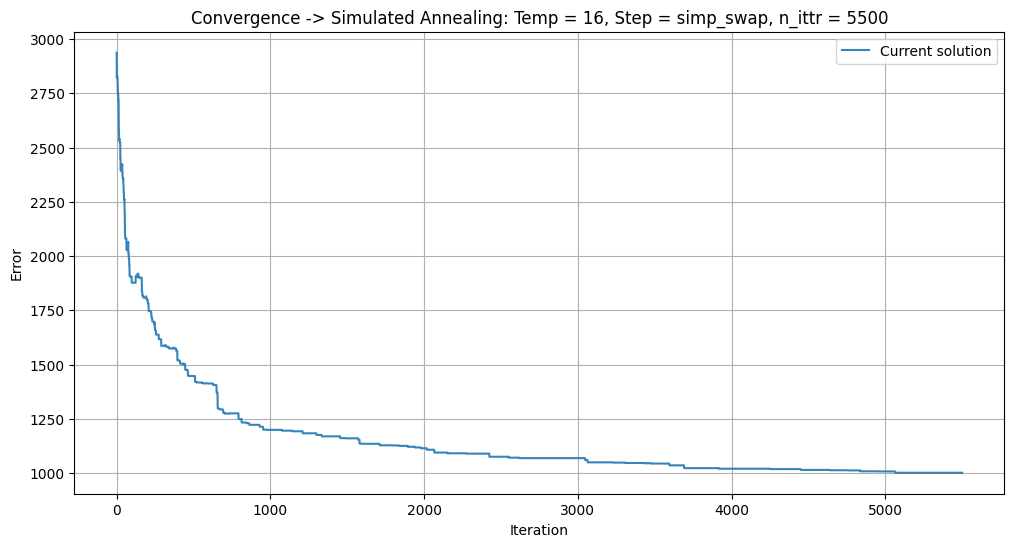

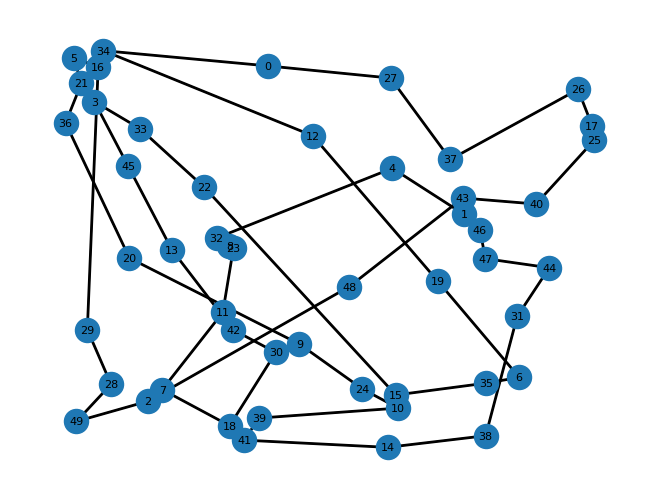

In [ ]:
#Simulated Annealing
rng = np.random.default_rng(seed=242)
sa_simp = SimulatedAnnealingTSP(df,step_size='simp_swap', n_iterations=5500)
sa_simp.temp = 16
sa_simp.get_node_parameters()
sa_simp.calc_distance_matrix()
best_simp_tour, shortest_distance_sa_simp,_  = sa_simp.simulated_annealing()
print(shortest_distance_sa_simp)
sa_simp.convergence_graphing()
sa_simp.vis_problem_space(best_simp_tour)

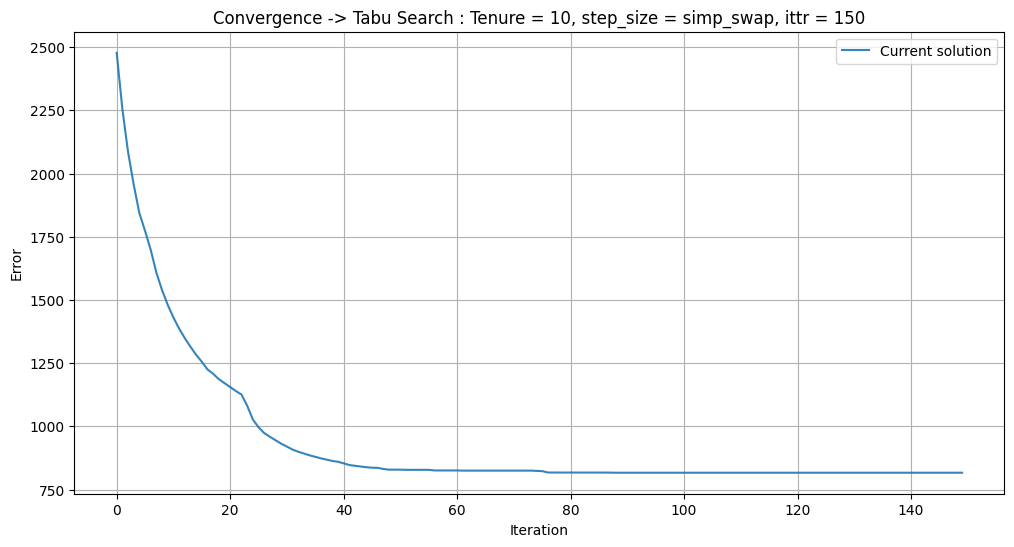

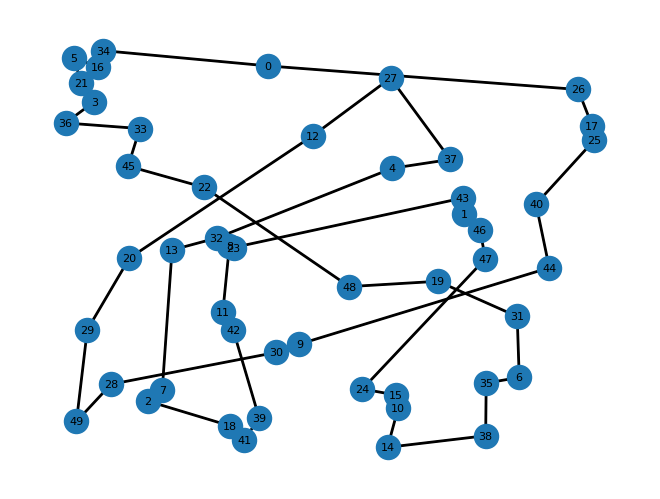

In [ ]:
#Tabu Search
rng = np.random.default_rng(seed=27)
tenure = 10
tbs_simp = TabuSearch(df,
                 tabu_tenure=tenure,
                 n_iterations=150,
                 lt_performance_weight=1)
tbs_simp.get_node_parameters()
tbs_simp.step_size = 'simp_swap'
tbs_simp.calc_distance_matrix()
best_tour_tbs_simp, shortest_distance_tbs_simp = tbs_simp.tabu_search()
tbs_simp.convergence_graphing()
tbs_simp.vis_problem_space(best_tour_tbs_simp)

Shortest tour ga simp_swap : 748.5936530421371


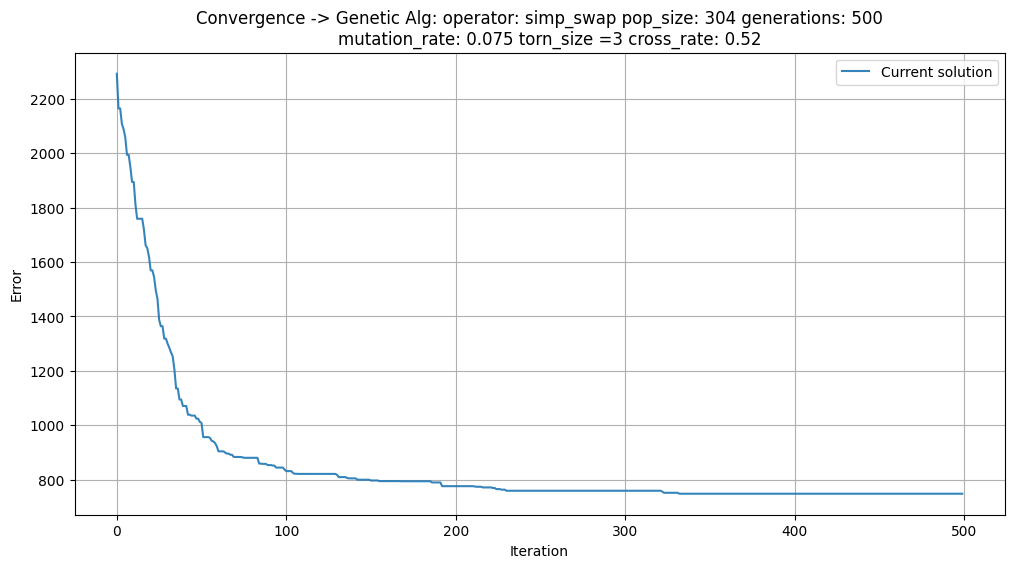

In [ ]:
rng = np.random.default_rng(seed=7)
ga_simp = GeneticAlgorithm(df,
                        population_size=304,
                        generations=500,
                        mutation_rate=  0.075,
                        crossover_rate= 0.52,
                        tornement_size=3,
                        operator='simp_swap')
ga_simp.get_node_parameters()
ga_simp.calc_distance_matrix()
best_tour_ga_simp, shortest_distance_ga_simp = ga_simp.genetic_algorithm()
print(f'Shortest tour ga simp_swap : {shortest_distance_ga_simp}')
ga_simp.convergence_graphing()

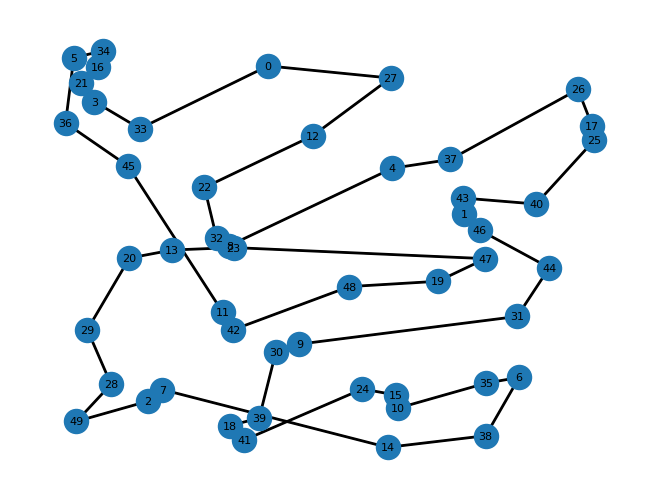

In [ ]:
ga_simp.vis_problem_space(best_tour_ga_simp)

In [ ]:
#Variation testing for simple swap GA
ga_simple_results = []
ga_simple_edge_avg = []

for seed in range(1, 11):
    rng = np.random.default_rng(seed=seed)
    ga_simp_var = GeneticAlgorithm(df,
                                   population_size=304,
                                   generations=500,
                                   mutation_rate=0.075,
                                   crossover_rate=0.52,
                                   tornement_size=3,
                                   operator='simp_swap')
    ga_simp_var.get_node_parameters()
    ga_simp_var.calc_distance_matrix()

    best_tour_ga_simp_var, shortest_distance_ga_simp_var = ga_simp_var.genetic_algorithm()
    ga_simple_edge_avg.append(ga_simp_var.average_edge_length(best_tour_ga_simp_var))

    print(f"Shortest Distance : {shortest_distance_ga_simp_var}")
    ga_simple_results.append(shortest_distance_ga_simp_var)

print(f"Mean: {np.mean(ga_simple_results)} std: {np.std(ga_simple_results)}")
print(f"Edge length Mean: {np.mean(ga_simple_edge_avg):.2f}")

Shortest Distance : 772.6247371464559
Shortest Distance : 762.1536078380252
Shortest Distance : 830.5836608689943
Shortest Distance : 643.6230597968072
Shortest Distance : 772.8348522104541
Shortest Distance : 748.0125732273663
Shortest Distance : 748.5936530421371
Shortest Distance : 842.2341588953753
Shortest Distance : 741.4650636886979
Shortest Distance : 693.2023858897636
Mean: 755.5327752604078 std: 55.22369511872063
Edge length Mean: 15.11


In [ ]:
#Variation testing for simple swap sa
sa_simple_results = []
sa_simple_edge_avg = []

for seed in range(1,11):
  rng = np.random.default_rng(seed=seed)
  sa_simp_var = SimulatedAnnealingTSP(df,step_size='simp_swap', n_iterations=5500)
  sa_simp_var.temp = 16
  sa_simp_var.get_node_parameters()
  sa_simp_var.calc_distance_matrix()

  best_tour_sa_simp_var, shortest_distance_sa_simp_var, _ = sa_simp_var.simulated_annealing()
  sa_simple_edge_avg.append(sa_simp_var.average_edge_length(best_tour_sa_simp_var))

  print(f"Shortest Distance : {shortest_distance_sa_simp_var}")
  #if shortest_distance_sa_tuned < 570:
    #print(f'Short: {shortest_distance_sa_tuned} @ seed {i + n}')
  sa_simple_results.append(shortest_distance_sa_simp_var)
print(f"Mean: {np.mean(sa_simple_results)} std: {np.std(sa_simple_results)} evals = {sa_simp_var.evaluation_count}")
print(f"Edge length Mean: {np.mean(sa_simple_edge_avg):.2f}")

/tmp/ipython-input-1572550436.py:68: RuntimeWarning: overflow encountered in exp
  metropolis = np.exp(-diff / t)


Shortest Distance : 840.1462934758848
Shortest Distance : 904.5975785346313
Shortest Distance : 851.2371532074624
Shortest Distance : 825.5834092709871
Shortest Distance : 891.2377627818325
Shortest Distance : 887.1762737676498
Shortest Distance : 934.9381062093136
Shortest Distance : 956.3303779271868
Shortest Distance : 930.7071554723574
Shortest Distance : 1036.1975663714713
Mean: 905.8151677018777 std: 59.42120862391377 evals = 5501
Edge length Mean: 18.12


In [ ]:
def timed(optim: TSP, ittr: int = 10):
  return timeit.timeit(optim, number=ittr) / ittr

execution_timing = {
'Hill Climbing (2opt)' : timed(hc.hill_climbing),
 'Hill Climbing (simp_swap)' : timed(hc_simp.hill_climbing),
'Simulated Annealing (2opt)' : timed(sa.simulated_annealing),
'Simulated Annealing (simp_swap)' : timed(sa_simp.simulated_annealing),
'Tabu Search (2opt)' :  timed(tbs.tabu_search),
'Tabu Search (simp_swap)' : timed(tbs_simp.tabu_search),
'Genetic Algorithm (inversion)' : timed(ga_solved.genetic_algorithm),
'Genetic Algorithm (simp_swap)' : timed(ga_simp.genetic_algorithm)
}

/tmp/ipython-input-1572550436.py:68: RuntimeWarning: overflow encountered in exp
  metropolis = np.exp(-diff / t)


# Comparison: Execution Time and Shortest Route

In [ ]:
#Comparison of various algorithms, relativly untuned
best_distances = [shortest_distance_hc,shortest_distance_hc_simp,
                  shortest_distance_sa, shortest_distance_sa_simp,
                  shortest_distance_tabu, shortest_distance_tbs_simp,
                  shortest_distance_ga_solved, shortest_distance_ga_simp ]

df_timings = pd.DataFrame(
    index=list(execution_timing.keys()),
    data={
        'Execution Time (50 Cities)': list(execution_timing.values()),
        'Shortest Distance (50 Cities)': best_distances
    }
)
df_timings

,Execution Time (50 Cities),Shortest Distance (50 Cities)
Hill Climbing (2opt),4.137248,559.864656
Hill Climbing (simp_swap),4.036823,828.164652
Simulated Annealing (2opt),0.399964,559.864656
Simulated Annealing (simp_swap),0.250628,1001.245800
Tabu Search (2opt),6.057334,559.864656
Tabu Search (simp_swap),6.061101,816.735328
Genetic Algorithm (inversion),11.013133,559.864656
Genetic Algorithm (simp_swap),10.995406,748.593653


In [ ]:
df_timings.to_csv('pre_comparison_alg_evaluations.csv')

In [ ]:
def less_cities(df_: pd.DataFrame = None, ga_: TSP = None , sa_:  TSP = None, display: bool = True):
  '''
  Description: Create stats for each algorithm, for cities less than 50.
  Optionally display stats.
  Return lists of shortest tour distances and average edge distance for each
  node/city

  '''
  #Store results and averages
  results_sa_ = []
  avg_edge_sa_ = []

  results_ga_ = []
  avg_edge_ga_ = []

  for s in range(1,11):
    rng = np.random.default_rng(seed=s)
    #Genetic Alg
    best_tour_ga_, shortest_distance_ga_ = ga_.genetic_algorithm(elite=False)
    results_ga_.append(shortest_distance_ga_)
    print('GA: ',shortest_distance_ga_)
    avg_edge_ga_.append(ga_.average_edge_length(best_tour_ga_))
    print('_'*75)
    #Simulated Ann
    best_tour_sa_, shortest_distance_sa_,_ = sa_.simulated_annealing()
    results_sa_.append(shortest_distance_sa_)
    print('SA: ',shortest_distance_sa_)
    print('='*75)
    avg_edge_sa_.append(sa_.average_edge_length(best_tour_sa_))

  if display == True:
    print(f'''Cites = {len(df_)}
    Genetic Algorithm:  Mean: {np.mean(results_ga_):.3f}, std: {np.std(results_ga_):.2f}, evals = {ga_.evaluation_count},
    Avg Edge Length: {np.mean(avg_edge_ga_)}
    Simulated Annealing: Mean: {np.mean(results_sa_):.3f}, std: {np.std(results_sa_):.2f}, evals = {sa_.evaluation_count}
    Avg Edge Length: {np.mean(avg_edge_sa_)}''')

  return results_ga_, avg_edge_ga_, results_sa_, avg_edge_sa_


In [ ]:
results_simple_ga_var, avg_edge_simple_ga_var, results_simple_sa_var, avg_edge_simple_sa_var =  less_cities(df, ga_simp_var, sa_simp_var)

GA:  753.707991143934
___________________________________________________________________________


/tmp/ipython-input-1572550436.py:68: RuntimeWarning: overflow encountered in exp
  metropolis = np.exp(-diff / t)


SA:  900.0261266779179
GA:  777.4689805316214
___________________________________________________________________________
SA:  815.4673299997472
GA:  764.9294487473006
___________________________________________________________________________
SA:  873.0930772048865
GA:  684.8420331072451
___________________________________________________________________________
SA:  942.1908839504447
GA:  705.3965713676117
___________________________________________________________________________
SA:  908.0546454947989
GA:  667.6835646146942
___________________________________________________________________________
SA:  861.4744196668249
GA:  701.0819721992377
___________________________________________________________________________
SA:  951.4718690143485
GA:  824.8258912849662
___________________________________________________________________________
SA:  985.3521987324771
GA:  803.0011878655639
___________________________________________________________________________
SA:  932.6438574129097
G


| Algorithm | Execution Time | Shortest Tour (50 Cities) |
| ----- | :---: | :---: |
| Hill Climbing (2opt) | 4.14 | 559.86 |
| Hill Climbing (simp\_swap) | 4.04 | 828.16 |
| Simulated Annealing (2opt) | 0.40 | 559.86 |
| Simulated Annealing (simp\_swap) | 0.25 | 1001.25 |
| Tabu Search (2opt) | 6.06 | 559.86 |
| Tabu Search (simp\_swap) | 6.06 | 816.74 |
| Genetic Algorithm (inversion) | 11.01 | 559.86 |
| Genetic Algorithm (simp\_swap) | 11.00 | 748.59 |

Table 2: Early Timings of Pre-Comparison Algorithms Convergence

#Main Comparison

## Simulated Annealing VS Genetic Algorithm

### Simulated Annealing (SA)
SA was chosen over similar algorithms due to its speed, as evidenced in Table 2. Other advantages to choosing SA are the relative ease of implementation, adaptability, ability to find ‘good-quality’ solutions (Siarry, P., 2016, p. 38).

Simulated Annealing avoids becoming stuck in local optima by occasionally accepting worse solutions. The chances of accepting worse solutions decrease with every iteration, which is referred to as ‘cooling’. At the beginning of a run, poorer solutions are more likely to be accepted if they are lower than the acceptance criterion, but as the temperature cools, the probability of accepting a worse solution lowers (Russel and Norvig, 2021, pp.131–133, 1076).

### Genetic Algorithm (GA)
GA mimics evolution: each solution consists of a series of genes, in this case representing individual cities in a ‘tour’. The strongest individuals are selected via competition, then ‘crossed’, then rearranged and merged to produce the child solutions which are ‘mutated’: One city swapped with another. Once this is completed, the two children are added back to the population, and the next generation repeats the process (Patrick Siarry, 2016, pp.117–119, 129–136, 151–154).

## Implementation Details
#### Shared Variation Operators
For Simulated Annealing, 2-opt was implemented, as was ‘inversion’ for the Genetic Algorithm -  these are functionally analogous. Both swap two cities, and invert the sub-tour between them (Siarry, 2016, p.153). The advantage is that this operator will always untangle TSP problems, eventually ensuring that no edges cross (Baeck, Fogel and Michalewicz, 2018, pp.19, 186).  

### Simulated Annealing Detail
The Metropolis acceptance criteria, ($e^{-ΔE/T}$ ) was used to determine the rate of cooling. This monitors the change in fitness ($E$) with respect to temperature $t$ - itself reduced, following initialisation, by the number of current iterations ($k$) and a constant ($a$), using geometric cooling ($T_{k + 1} = a * T_k$) (Siarry. P, 2016, pp.21–22).

### Genetic Algorithm Detail
Tournament selection uses a pool of solutions of size k, to be evaluated alongside one another, and the fittest progressed.

Order Crossover merges the order of two existing tours, by removing random-length sub-tours from one tour and recombing them within ‘holes’ in a second tour, all within a new child, only if the element does not already exist in the second tour (Baeck, Fogel and Michalewicz, 2018, p.73).



### Experiment Details

 Ten comparative runs using SA and GA were made over 5 problem spaces where the total number cities were [50, 40, 30, 20, 10] respectively.

 Along with the mean lowest distance (shortest route), the average edge-length between nodes and standard deviation was recorded, the latter equated with robustness. i.e. how well an algorithm might behave given some unforeseen circumstances.

Average execution times were recorded and ‘perfect’ runs demonstrated, using selective seeding and 2-opt implemented algorithms to demonstrate ability to discover optimal solutions to the TSP.


### Metrics: 10 Runs - 50 cities




#### Simulated Annealing

In [ ]:
for n in range(0,1):
  sa_tune_results = []
  sa_tuned_edge_avg = []
  sa_tuned = SimulatedAnnealingTSP(df,
                              temperature= 7,#6.9, #6.9 + (t/100), #6.9
                              step_size='2opt',
                                   alpha= 0.99502, #0.99502
                              n_iterations=5000) #5500
  sa_tuned.get_node_parameters()
  sa_tuned.calc_distance_matrix()
  for i in range(1,11):
    rng = np.random.default_rng(seed=i)
    best_tour_sa, shortest_distance_sa_tuned, best_scores_tuned = sa_tuned.simulated_annealing()
    sa_tuned_edge_avg.append(sa_tuned.average_edge_length(best_tour_sa))

    print(f"Shortest Distance : {shortest_distance_sa_tuned}")
    #if shortest_distance_sa_tuned < 570:
      #print(f'Short: {shortest_distance_sa_tuned} @ seed {i + n}')
    sa_tune_results.append(shortest_distance_sa_tuned)
  print(f"Mean: {np.mean(sa_tune_results)} std: {np.std(sa_tune_results)} evals = {sa_tuned.evaluation_count}")
  print(f"Edge length Mean: {np.mean(sa_tuned_edge_avg):.2f}")

/tmp/ipython-input-1572550436.py:68: RuntimeWarning: overflow encountered in exp
  metropolis = np.exp(-diff / t)


Shortest Distance : 619.4021909261753
Shortest Distance : 636.1256196494317
Shortest Distance : 617.7799086415114
Shortest Distance : 619.7828578907447
Shortest Distance : 622.9535675517259
Shortest Distance : 612.4711446551167
Shortest Distance : 620.0405231627856
Shortest Distance : 636.8977272191439
Shortest Distance : 623.3695868540117
Shortest Distance : 667.5617850862623
Mean: 627.6384911636909 std: 15.186583012874628 evals = 5001
Edge length Mean: 12.55


#### Genetic Algorithm

In [ ]:

for pop in range(0,1):
  #Initialise Env
  ga_results = []
  ga_50_edge_avg = []
  ga = GeneticAlgorithm(df,
                        population_size=300,#Mean: 587.400102107916 std: 9.784733558545613 @ tourne_size 286)
                        generations=500, #500
                        mutation_rate=  0.075, #0.085, #0.085
                        crossover_rate= 0.52, #0.99
                        tornement_size=3, #3 or 7 (3 lower std, 7 better mean. Mean only slightly better)
                        operator='inversion') #inversion
  ga.get_node_parameters()
  ga.calc_distance_matrix()
  for i in range(1,11):
    rng = np.random.default_rng(seed=i)#27
    #ga.op '#Uses swapping operator
    #Run Alg
    best_tour_ga, shortest_distance_ga = ga.genetic_algorithm(elite=False)
    print(f'Shortest tour ga : {shortest_distance_ga} seed @ {i}')
    ga_results.append(shortest_distance_ga)
    ga_50_edge_avg.append(ga.average_edge_length(best_tour_ga))
  print(f"Mean: {np.mean(ga_results)} std: {np.std(ga_results)} evals = {ga.evaluation_count}")
  print(f"Edge length Mean: {np.mean(ga_50_edge_avg):.2f}")
#ga.convergence_graphing()

Shortest tour ga : 572.5482604831595 seed @ 1
Shortest tour ga : 582.7402850179151 seed @ 2
Shortest tour ga : 580.9020996253548 seed @ 3
Shortest tour ga : 590.7365659467085 seed @ 4
Shortest tour ga : 593.7231786303671 seed @ 5
Shortest tour ga : 590.2197311749128 seed @ 6
Shortest tour ga : 583.0017935258654 seed @ 7
Shortest tour ga : 607.2614169225634 seed @ 8
Shortest tour ga : 575.7410779220028 seed @ 9
Shortest tour ga : 589.5737714624346 seed @ 10
Mean: 586.6448180711284 std: 9.44642162499628 evals = 150001
Edge length Mean: 11.73


### Metrics: 10 Runs - 40 cities

In [ ]:
df_40 = df[:40]
print(len(df_40))

40


In [ ]:
#Genetic Algorithm 40 city
ga_40 = GeneticAlgorithm(df_40,
                        population_size=300,
                        generations=500,
                        mutation_rate=  0.075,
                        crossover_rate= 0.52,
                        tornement_size=3,
                        operator='inversion')
ga_40.get_node_parameters()
ga_40.calc_distance_matrix()
#Simulated Annealing 40 city
sa_40 = SimulatedAnnealingTSP(df_40,
                              temperature= 7,
                              step_size='2opt',
                                   alpha= 0.99502,
                              n_iterations=5000)
sa_40.get_node_parameters()
sa_40.calc_distance_matrix()

In [ ]:
results_ga_40, avg_edge_ga_40, results_sa_40, avg_edge_sa_40 = less_cities(df_40, ga_40, sa_40)

GA:  538.9907265483033
___________________________________________________________________________


/tmp/ipython-input-1572550436.py:68: RuntimeWarning: overflow encountered in exp
  metropolis = np.exp(-diff / t)


SA:  502.8535537124267
GA:  522.3368096308598
___________________________________________________________________________
SA:  540.3837879543534
GA:  490.3915626745449
___________________________________________________________________________
SA:  508.0712428326491
GA:  553.4036008322797
___________________________________________________________________________
SA:  495.742595033823
GA:  536.5578576230785
___________________________________________________________________________
SA:  521.1483313276244
GA:  553.9284537256135
___________________________________________________________________________
SA:  492.29360626956617
GA:  498.13200617096396
___________________________________________________________________________
SA:  509.2370581127115
GA:  515.496471712513
___________________________________________________________________________
SA:  496.3760717971983
GA:  496.40252019605794
___________________________________________________________________________
SA:  554.9463149502702


### Metrics: 10 Runs - 30 cities

In [ ]:
df_30 = df[:30]
print(len(df_30))

30


In [ ]:
#Genetic Algorithm 30 city
ga_30 = GeneticAlgorithm(df_30,
                        population_size=300,
                        generations=500,
                        mutation_rate=  0.075,
                        crossover_rate= 0.52,
                        tornement_size=3,
                        operator='inversion')
ga_30.get_node_parameters()
ga_30.calc_distance_matrix()
#Simulated Annealing 30 city
sa_30 = SimulatedAnnealingTSP(df_30,
                              temperature= 7,
                              step_size='2opt',
                                   alpha= 0.99502,
                              n_iterations=5000)
sa_30.get_node_parameters()
sa_30.calc_distance_matrix()

In [ ]:
results_ga_30, avg_edge_ga_30, results_sa_30, avg_edge_sa_30 = less_cities(df_30, ga_30, sa_30)

GA:  458.5713140651967
___________________________________________________________________________
SA:  488.67447612679325


/tmp/ipython-input-1572550436.py:68: RuntimeWarning: overflow encountered in exp
  metropolis = np.exp(-diff / t)


GA:  458.5713140651967
___________________________________________________________________________
SA:  484.97278690189245
GA:  487.2825907069628
___________________________________________________________________________
SA:  459.8936911237574
GA:  453.9023021201498
___________________________________________________________________________
SA:  459.89369112375743
GA:  494.905551746015
___________________________________________________________________________
SA:  515.0763539286207
GA:  459.89369112375743
___________________________________________________________________________
SA:  509.88573001094375
GA:  504.1207121896304
___________________________________________________________________________
SA:  512.5545680714743
GA:  458.5344690752071
___________________________________________________________________________
SA:  494.97308539020247
GA:  466.66115941406605
___________________________________________________________________________
SA:  491.938891816568
GA:  491.93889181656

### Metrics: 10 Runs - 20 cities

In [ ]:
df_20 = df[:20]
print(len(df_20))

20


In [ ]:
#Genetic Algorithm 20 city
ga_20 = GeneticAlgorithm(df_20,
                        population_size=300,
                        generations=500,
                        mutation_rate=  0.075,
                        crossover_rate= 0.52,
                        tornement_size=3,
                        operator='inversion')
ga_20.get_node_parameters()
ga_20.calc_distance_matrix()
#Simulated Annealing 20 city
sa_20 = SimulatedAnnealingTSP(df_20,
                              temperature= 7,
                              step_size='2opt',
                                   alpha= 0.99502,
                              n_iterations=5000)
sa_20.get_node_parameters()
sa_20.calc_distance_matrix()

In [ ]:
results_ga_20, avg_edge_ga_20, results_sa_20, avg_edge_sa_20 = less_cities(df_20, ga_20, sa_20)

GA:  386.6266770171125
___________________________________________________________________________
SA:  386.6266770171124
GA:  386.6266770171124
___________________________________________________________________________
SA:  443.47820389004283
GA:  386.6266770171124
___________________________________________________________________________
SA:  386.42968948346993
GA:  386.62667701711246
___________________________________________________________________________
SA:  386.42968948347
GA:  386.42968948346993
___________________________________________________________________________
SA:  386.62667701711246
GA:  386.6266770171125
___________________________________________________________________________
SA:  386.42968948346993
GA:  386.42968948347
___________________________________________________________________________
SA:  386.6266770171124
GA:  386.42968948347
___________________________________________________________________________
SA:  386.6266770171124
GA:  386.62667701711246


### Metrics: 10 Runs - 10 cities

In [ ]:
df_10 = df[:10]
print(len(df_10))

10


In [ ]:
#Genetic Algorithm 10 city
ga_10 = GeneticAlgorithm(df_10,
                        population_size=300,
                        generations=500,
                        mutation_rate=  0.075,
                        crossover_rate= 0.52,
                        tornement_size=3,
                        operator='inversion')
ga_10.get_node_parameters()
ga_10.calc_distance_matrix()
#Simulated Annealing 10 city
sa_10 = SimulatedAnnealingTSP(df_10,
                              temperature= 7,
                              step_size='2opt',
                                   alpha= 0.99502,
                              n_iterations=5000)
sa_10.get_node_parameters()
sa_10.calc_distance_matrix()

In [ ]:
results_ga_10, avg_edge_ga_10, results_sa_10, avg_edge_sa_10 = less_cities(df_10, ga_10, sa_10)

GA:  290.30677379181276
___________________________________________________________________________
SA:  290.30677379181276
GA:  290.3067737918128
___________________________________________________________________________
SA:  290.30677379181276
GA:  290.30677379181276
___________________________________________________________________________
SA:  290.30677379181276
GA:  290.3067737918128
___________________________________________________________________________
SA:  290.30677379181276
GA:  290.3067737918128
___________________________________________________________________________
SA:  290.30677379181276
GA:  290.30677379181276
___________________________________________________________________________
SA:  290.30677379181276
GA:  290.3067737918128
___________________________________________________________________________
SA:  290.30677379181276
GA:  290.3067737918128
___________________________________________________________________________
SA:  290.30677379181276
GA:  290.3067

#### Timed Execution

In [ ]:
comparison_timings_sa = {
    'Simulated Annealing 50 Cities': timed(sa_tuned.simulated_annealing),
    'Simulated Annealing 40 Cities': timed(sa_40.simulated_annealing),
    'Simulated Annealing 30 Cities': timed(sa_30.simulated_annealing),
    'Simulated Annealing 20 Cities': timed(sa_20.simulated_annealing),
    'Simulated Annealing 10 Cities': timed(sa_10.simulated_annealing),
}

/tmp/ipython-input-1572550436.py:68: RuntimeWarning: overflow encountered in exp
  metropolis = np.exp(-diff / t)


In [ ]:
comparison_timings_sa

{'Simulated Annealing 50 Cities': 0.24738398360022984,
 'Simulated Annealing 40 Cities': 0.23129384220010252,
 'Simulated Annealing 30 Cities': 0.20534183109994048,
 'Simulated Annealing 20 Cities': 0.19054374739971536,
 'Simulated Annealing 10 Cities': 0.22612138289987344}

In [ ]:
comparison_timings_ga = {
    'Genetic Algorithm 50 Cities': timed(ga.genetic_algorithm),
    'Genetic Algorithm 40 Cities': timed(ga_40.genetic_algorithm),
    'Genetic Algorithm 30 Cities': timed(ga_30.genetic_algorithm),
    'Genetic Algorithm 20 Cities': timed(ga_20.genetic_algorithm),
    'Genetic Algorithm 10 Cities': timed(ga_10.genetic_algorithm),
}

In [ ]:
comparison_timings_ga

{'Genetic Algorithm 50 Cities': 10.832332365299953,
 'Genetic Algorithm 40 Cities': 9.373264128600203,
 'Genetic Algorithm 30 Cities': 7.902710582600048,
 'Genetic Algorithm 20 Cities': 6.693044483400081,
 'Genetic Algorithm 10 Cities': 5.653425295399939}

#### Other Statistics

In [ ]:
stats_ga = {
    '50': [np.mean(ga_results), np.std(ga_results), np.mean(ga_50_edge_avg) ],
    '40': [np.mean(results_ga_40 ), np.std(results_ga_40), np.mean(avg_edge_ga_40) ],
    '30': [np.mean(results_ga_30 ), np.std(results_ga_30), np.mean(avg_edge_ga_30)],
    '20': [np.mean(results_ga_20 ), np.std(results_ga_20), np.mean(avg_edge_ga_20)],
    '10': [np.mean(results_ga_10 ), np.std(results_ga_10), np.mean(avg_edge_ga_10)],
}

In [ ]:
stats_sa = {
    '50': [np.mean(sa_tune_results), np.std(sa_tune_results), np.mean(sa_tuned_edge_avg)],
    '40': [np.mean(results_sa_40 ), np.std(results_sa_40), np.mean(avg_edge_sa_40) ],
    '30': [np.mean(results_sa_30 ), np.std(results_sa_30), np.mean(avg_edge_sa_30)],
    '20': [np.mean(results_sa_20 ), np.std(results_sa_20), np.mean(avg_edge_sa_20)],
    '10': [np.mean(results_sa_10 ), np.std(results_sa_10), np.mean(avg_edge_sa_10)],
}

# Results and Analysis

In [ ]:
#Asked claude to put this together
cities = ['50', '40', '30', '20', '10']

# Add execution times
for c in cities:
    stats_ga[c].append(comparison_timings_ga[f'Genetic Algorithm {c} Cities'])
    stats_sa[c].append(comparison_timings_sa[f'Simulated Annealing {c} Cities'])

# Build dataframes
df_sa = pd.DataFrame(stats_sa, index=[
    'Avg Convergence',
    'Convergence Variation (std)',
    'Avg Edge Length',
    'Avg Execution Time (sec)'
])

df_ga = pd.DataFrame(stats_ga, index=[
    'Avg Convergence',
    'Convergence Variation (std)',
    'Avg Edge Length',
    'Avg Execution Time'
])

final_df = pd.concat({
    'Simulated Annealing': df_sa,
    'Genetic Algorithm': df_ga
})

#print(final_df)
final_df.to_csv('comparison_table_adjusted.csv')

In [ ]:
final_df

50          40  \
Simulated Annealing Avg Convergence              627.638491  513.293476   
                    Convergence Variation (std)   15.186583   19.288544   
                    Avg Edge Length               12.552770   12.832337   
                    Avg Execution Time (sec)       0.247384    0.231294   
Genetic Algorithm   Avg Convergence              586.644818  519.891908   
                    Convergence Variation (std)    9.446422   23.565004   
                    Avg Edge Length               11.732896   12.997298   
                    Avg Execution Time            10.832332    9.373264   

                                                         30          20  \
Simulated Annealing Avg Convergence              488.575171  392.213336   
                    Convergence Variation (std)   19.672048   17.088542   
                    Avg Edge Length               16.285839   19.610667   
                    Avg Execution Time (sec)       0.205342    0.190544   
Genetic Algorithm   Avg Convergence              473.438200  386.547882   
                    Convergence Variation (std)   17.920406    0.096504   
                    Avg Edge Length               15.781273   19.327394   
                    Avg Execution Time             7.902711    6.693044   

                                                           10  
Simulated Annealing Avg Convergence              2.903068e+02  
                    Convergence Variation (std)  0.000000e+00  
                    Avg Edge Length              2.903068e+01  
                    Avg Execution Time (sec)     2.261214e-01  
Genetic Algorithm   Avg Convergence              2.903068e+02  
                    Convergence Variation (std)  3.113442e-14  
                    Avg Edge Length              2.903068e+01  
                    Avg Execution Time           5.653425e+00

In [ ]:
#This collects 2opt (tuned) and simple_swap stats and collects them in one DF
comparison_df = pd.DataFrame({ # requested from claude.ai
    'GA (Tuned)': [
        df_ga['50']['Avg Convergence'],
        df_ga['50']['Convergence Variation (std)'],
        df_ga['50']['Avg Edge Length']
    ],
    'GA (Simple Swap)': [
        np.mean(results_simple_ga_var),
        np.std(results_simple_ga_var),
        np.mean(avg_edge_simple_ga_var)
    ],
    'SA (Tuned)': [
        df_sa['50']['Avg Convergence'],
        df_sa['50']['Convergence Variation (std)'],
        df_sa['50']['Avg Edge Length']
    ],
    'SA (Simple Swap)': [
        np.mean(results_simple_sa_var),
        np.std(results_simple_sa_var),
        np.mean(avg_edge_simple_sa_var)
    ]
}, index=[
    'Avg Convergence',
    'Convergence Variation (std)',
    'Avg Edge Length'
])

comparison_df

,GA (Tuned),GA (Simple Swap),SA (Tuned),SA (Simple Swap)
Avg Convergence,586.644818,744.982607,627.638491,917.589042
Convergence Variation (std),9.446422,49.836427,15.186583,55.105136
Avg Edge Length,11.732896,14.899652,12.552770,18.351781


In [ ]:
comparison_df.to_csv('operator_comparisons.csv')

### Comparative Graphs

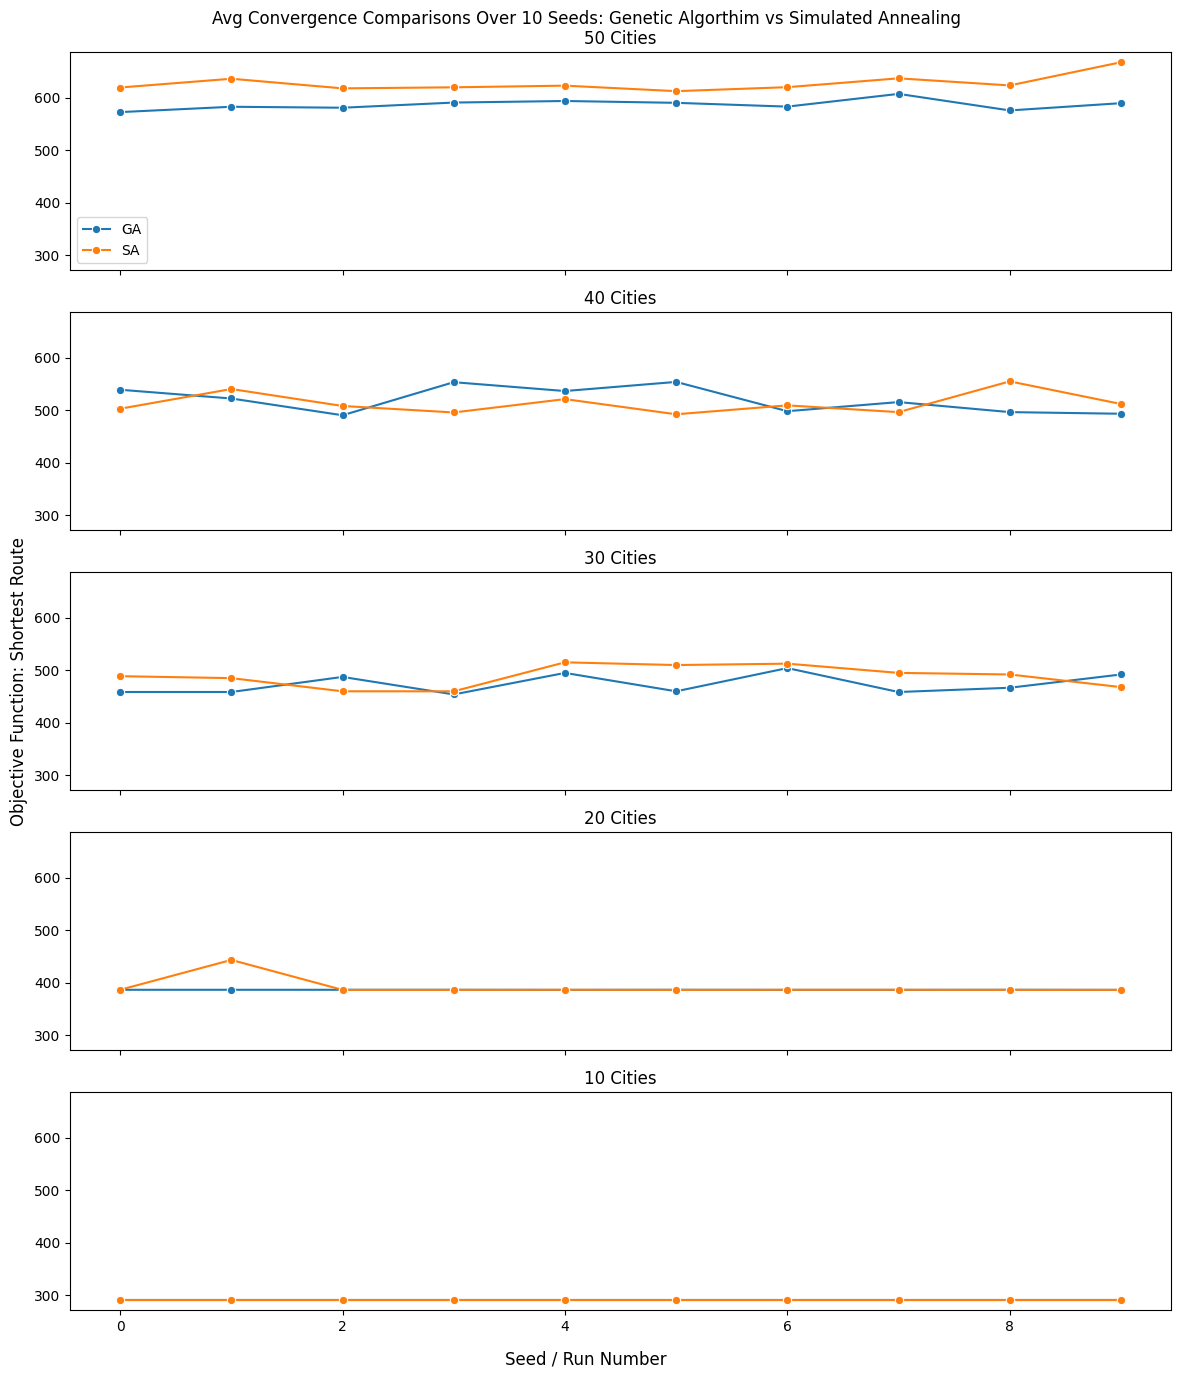

In [ ]:
# @title
import seaborn as sns #adapted from claude.ai code
fig, ax = plt.subplots(
    nrows=5,
    ncols=1,
    figsize=(12, 14),
    sharex=True,
    sharey=True)

x_val = [x for x in range(len(ga_results))]
#50
ax[0].set_title('50 Cities')
sns.lineplot(x=x_val,y=ga_results, ax=ax[0], label="GA", marker='o')
sns.lineplot(x=x_val,y=sa_tune_results, ax=ax[0], label="SA",marker='o')
#40
ax[1].set_title('40 Cities')
sns.lineplot(x=x_val,y=results_ga_40, ax=ax[1],marker='o')
sns.lineplot(x=x_val,y=results_sa_40, ax=ax[1],marker='o')
#30
ax[2].set_title('30 Cities')
sns.lineplot(x=x_val,y=results_ga_30, ax=ax[2],marker='o')
sns.lineplot(x=x_val,y=results_sa_30, ax=ax[2],marker='o')
#20
ax[3].set_title('20 Cities')
sns.lineplot(x=x_val,y=results_ga_20, ax=ax[3],marker='o')
sns.lineplot(x=x_val,y=results_sa_20, ax=ax[3],marker='o')
#10
ax[4].set_title('10 Cities')
sns.lineplot(x=x_val,y=results_ga_10, ax=ax[4],marker='o')
sns.lineplot(x=x_val,y=results_sa_10, ax=ax[4],marker='o')
fig.suptitle('Avg Convergence Comparisons Over 10 Seeds: Genetic Algorthim vs Simulated Annealing')
fig.supylabel('Objective Function: Shortest Route')
fig.supxlabel('Seed / Run Number')

plt.tight_layout()
#plt.savefig('Avg_Convergence.png')
plt.show()

Timings for 'perfect' runs

In [ ]:
ga_times = timeit.timeit(ga_solved.genetic_algorithm, number= 10)
sa_times = timeit.timeit(sa_tuned.simulated_annealing, number = 10 )

/tmp/ipython-input-1572550436.py:68: RuntimeWarning: overflow encountered in exp
  metropolis = np.exp(-diff / t)


In [ ]:
ga_times = []
sa_times = []
for seed in range(1,11):
  rng = np.random.default_rng(seed=seed)
  ga_times.append(timed(ga_solved.genetic_algorithm, 1))
  sa_times.append(timed(sa_tuned.simulated_annealing, 1))

/tmp/ipython-input-1572550436.py:68: RuntimeWarning: overflow encountered in exp
  metropolis = np.exp(-diff / t)


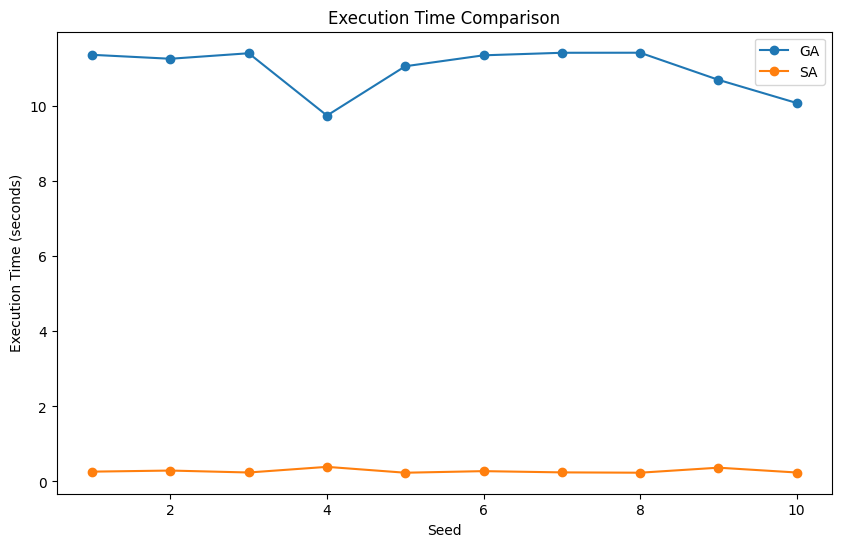

GA avg: 10.99s, SA avg: 0.28s


In [ ]:
#Claude again. Just quick graphing code for execution time comparison
plt.figure(figsize=(10, 6))
plt.plot(range(1, 11), ga_times, label='GA', marker='o')
plt.plot(range(1, 11), sa_times, label='SA', marker='o')
plt.xlabel('Seed')
plt.ylabel('Execution Time (seconds)')
plt.title('Execution Time Comparison')
plt.legend()
#plt.savefig('execution_times.png')
plt.show()

print(f"GA avg: {np.mean(ga_times):.2f}s, SA avg: {np.mean(sa_times):.2f}s")

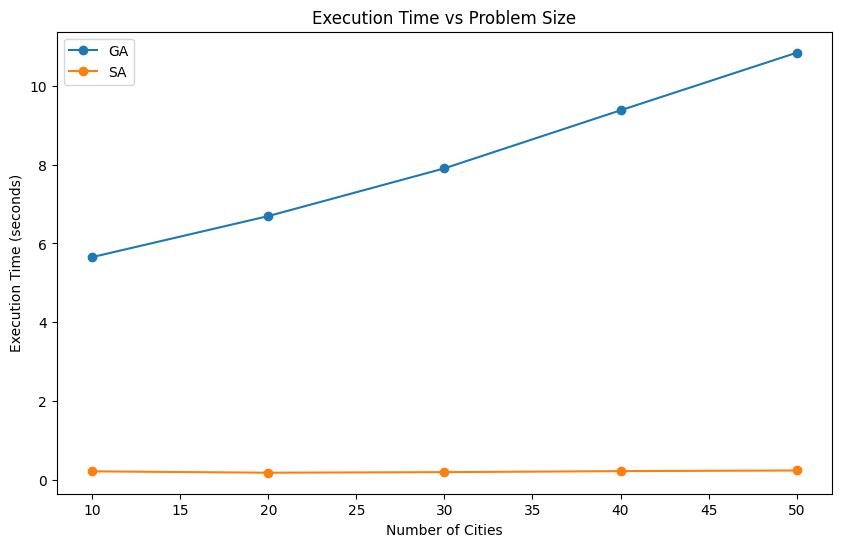

In [ ]:
#Extract from timing dicts   (generated code)
cities = [10, 20, 30, 40, 50]
ga_times = [
    comparison_timings_ga['Genetic Algorithm 10 Cities'],
    comparison_timings_ga['Genetic Algorithm 20 Cities'],
    comparison_timings_ga['Genetic Algorithm 30 Cities'],
    comparison_timings_ga['Genetic Algorithm 40 Cities'],
    comparison_timings_ga['Genetic Algorithm 50 Cities'],
]
sa_times = [
    comparison_timings_sa['Simulated Annealing 10 Cities'],
    comparison_timings_sa['Simulated Annealing 20 Cities'],
    comparison_timings_sa['Simulated Annealing 30 Cities'],
    comparison_timings_sa['Simulated Annealing 40 Cities'],
    comparison_timings_sa['Simulated Annealing 50 Cities'],
]

plt.figure(figsize=(10, 6))
plt.plot(cities, ga_times, label='GA', marker='o')
plt.plot(cities, sa_times, label='SA', marker='o')
plt.xlabel('Number of Cities')
plt.ylabel('Execution Time (seconds)')
plt.title('Execution Time vs Problem Size')
plt.legend()
#plt.savefig('time_scaling.png')
plt.show()